 Sentiment Analysis

## Project Overview

This project performs sentiment analysis on Amazon customer reviews using Natural Language Processing (NLP).

The reviews are classified into:
- Positive
- Negative
- Neutral

The project also performs basic emotion detection and exploratory data analysis to understand customer opinions and trends.

## Objectives

- Clean and preprocess text data
- Apply NLP techniques
- Perform sentiment analysis
- Detect emotions from customer reviews
- Visualize sentiment patterns
- Generate business insights

In [1]:
!pip install pandas numpy matplotlib nltk wordcloud

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------- ---------------------- 0.8/1.8 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 4.8 MB/s  0:00:00

   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   -------- ------------------------------- 1/5 [regex]
   -------- ------------------------------- 1/5 [regex]
   ---------------- ----------------------- 2/5 [click]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   ------------------------ --------------- 3/5 [nltk]
   -----

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from collections import Counter

In [3]:
nltk.download('vader_lexicon')
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [4]:
url = "https://raw.githubusercontent.com/pplonski/datasets-for-start/master/amazon-fine-food-reviews/amazon_fine_food_reviews_10k.csv"

df = pd.read_csv(url)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 10


In [7]:
print(df.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Id                      10000 non-null  int64
 1   ProductId               10000 non-null  str  
 2   UserId                  10000 non-null  str  
 3   ProfileName             10000 non-null  str  
 4   HelpfulnessNumerator    10000 non-null  int64
 5   HelpfulnessDenominator  10000 non-null  int64
 6   Score                   10000 non-null  int64
 7   Time                    10000 non-null  int64
 8   Summary                 10000 non-null  str  
 9   Text                    10000 non-null  str  
dtypes: int64(5), str(5)
memory usage: 781.4 KB


In [9]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (10000, 10)


In [12]:
df["Review"] = (
    df["Summary"].fillna("") + " " +
    df["Text"].fillna("")
)

df["Review"].head()

0    Good Quality Dog Food I have bought several of...
1    Not as Advertised Product arrived labeled as J...
2    "Delight" says it all This is a confection tha...
3    Cough Medicine If you are looking for the secr...
4    Great taffy Great taffy at a great price.  The...
Name: Review, dtype: str

In [13]:
def clean_text(text):
    text = str(text)
    
    text = text.lower()
    
    text = re.sub(r'<.*?>', ' ', text)
    
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [14]:
df["Clean_Review"] = df["Review"].apply(clean_text)

df[["Review", "Clean_Review"]].head()

,Review,Clean_Review
0,Good Quality Dog Food I have bought several of...,good quality dog food i have bought several of...
1,Not as Advertised Product arrived labeled as J...,not as advertised product arrived labeled as j...
2,"""Delight"" says it all This is a confection tha...",delight says it all this is a confection that ...
3,Cough Medicine If you are looking for the secr...,cough medicine if you are looking for the secr...
4,Great taffy Great taffy at a great price. The...,great taffy great taffy at a great price there...


In [15]:
df["Review_Length"] = df["Clean_Review"].str.len()

df[["Clean_Review", "Review_Length"]].head()

,Clean_Review,Review_Length
0,good quality dog food i have bought several of...,281
1,not as advertised product arrived labeled as j...,202
2,delight says it all this is a confection that ...,505
3,cough medicine if you are looking for the secr...,227
4,great taffy great taffy at a great price there...,144


In [16]:
rating_counts = df["Score"].value_counts().sort_index()

print(rating_counts)

Score
1     932
2     590
3     862
4    1433
5    6183
Name: count, dtype: int64


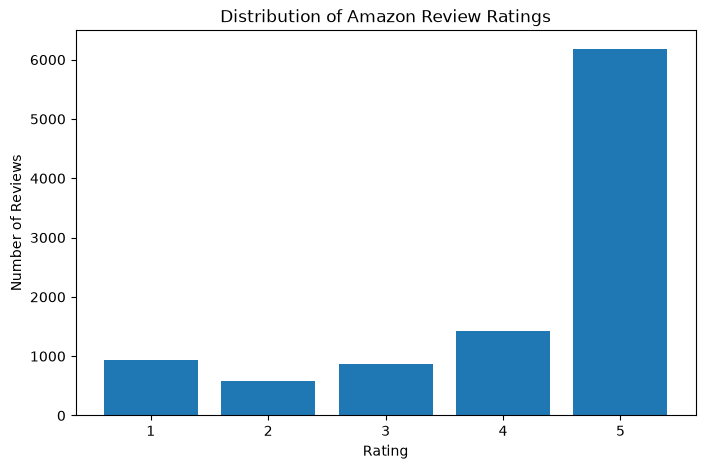

In [17]:
plt.figure(figsize=(8,5))

plt.bar(rating_counts.index, rating_counts.values)

plt.title("Distribution of Amazon Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.xticks([1, 2, 3, 4, 5])

plt.show()

In [18]:
sia = SentimentIntensityAnalyzer()

In [19]:
df["Sentiment_Score"] = df["Clean_Review"].apply(
    lambda text: sia.polarity_scores(text)["compound"]
)

df[["Clean_Review", "Sentiment_Score"]].head()

,Clean_Review,Sentiment_Score
0,good quality dog food i have bought several of...,0.9583
1,not as advertised product arrived labeled as j...,-0.5664
2,delight says it all this is a confection that ...,0.9116
3,cough medicine if you are looking for the secr...,0.4404
4,great taffy great taffy at a great price there...,0.9661


In [20]:
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [21]:
df["Sentiment"] = df["Sentiment_Score"].apply(classify_sentiment)

df[["Clean_Review", "Sentiment_Score", "Sentiment"]].head(10)

,Clean_Review,Sentiment_Score,Sentiment
0,good quality dog food i have bought several of...,0.9583,Positive
1,not as advertised product arrived labeled as j...,-0.5664,Negative
2,delight says it all this is a confection that ...,0.9116,Positive
3,cough medicine if you are looking for the secr...,0.4404,Positive
4,great taffy great taffy at a great price there...,0.9661,Positive
5,nice taffy i got a wild hair for taffy and ord...,0.8875,Positive
6,great just as good as the expensive brands thi...,0.9665,Positive
7,wonderful tasty taffy this taffy is so good it...,0.9625,Positive
8,yay barley right now i m mostly just sprouting...,0.8225,Positive
9,healthy dog food this is a very healthy dog fo...,0.8807,Positive


In [22]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    8892
Negative     960
Neutral      148
Name: count, dtype: int64


In [23]:
sentiment_percentage = (
    df["Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_percentage)

Sentiment
Positive    88.92
Negative     9.60
Neutral      1.48
Name: proportion, dtype: float64


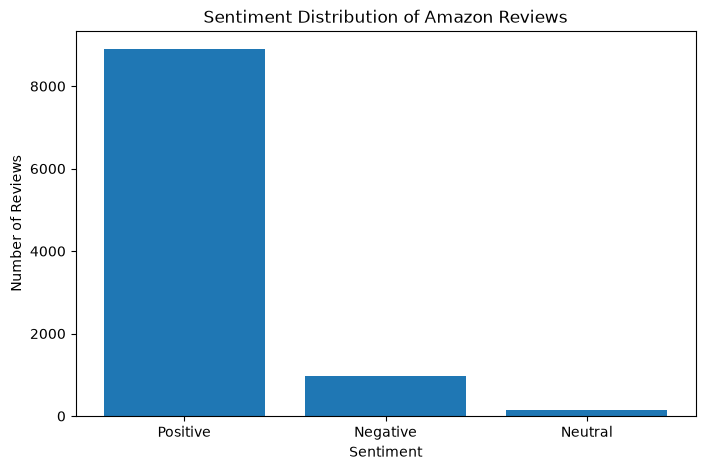

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title("Sentiment Distribution of Amazon Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

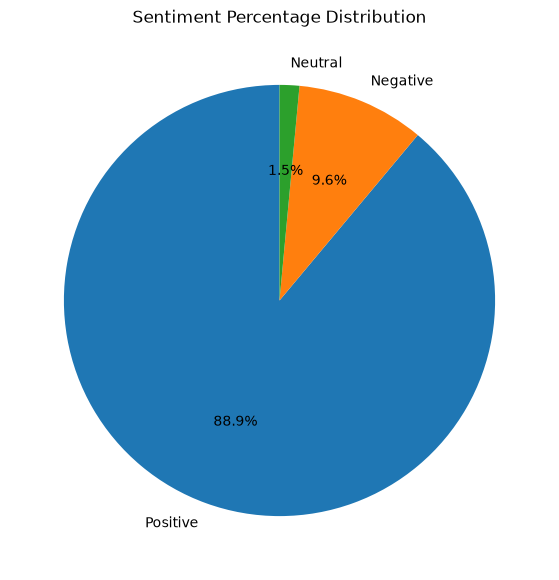

In [25]:
plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sentiment Percentage Distribution")

plt.show()

In [26]:
positive_reviews = df[df["Sentiment"] == "Positive"]

positive_reviews[["Score", "Review"]].head(10)

,Score,Review
0,5,Good Quality Dog Food I have bought several of...
2,4,"""Delight"" says it all This is a confection tha..."
3,2,Cough Medicine If you are looking for the secr...
4,5,Great taffy Great taffy at a great price. The...
5,4,Nice Taffy I got a wild hair for taffy and ord...
6,5,Great! Just as good as the expensive brands! ...
7,5,"Wonderful, tasty taffy This taffy is so good. ..."
8,5,Yay Barley Right now I'm mostly just sprouting...
9,5,Healthy Dog Food This is a very healthy dog fo...
10,5,The Best Hot Sauce in the World I don't know i...


In [27]:
negative_reviews = df[df["Sentiment"] == "Negative"]

negative_reviews[["Score", "Review"]].head(10)

,Score,Review
1,1,Not as Advertised Product arrived labeled as J...
26,1,"Nasty No flavor The candy is just red , No fla..."
52,4,You'll go nuts over Ass-Kickin' Peanuts. This ...
67,2,Taste is not so good. I purchased the Mango fl...
68,3,How much would you pay for a bag of chocolate ...
69,5,pretzel haven! this was sooooo deliscious but ...
74,2,nothing special It is okay. I would not go ou...
75,1,No Tea Flavor No tea flavor at all. Just whole...
99,1,Bad I fed this to my Golden Retriever and he h...
110,2,Low Carb Angel Food Puffs I was diappointed in...


In [28]:
neutral_reviews = df[df["Sentiment"] == "Neutral"]

neutral_reviews[["Score", "Review"]].head(10)

,Score,Review
25,5,Twizzlers - Strawberry Product received is as ...
62,1,stale product. Arrived in 6 days and were so s...
94,5,So convenient This is the same food we get at ...
235,2,"Taste is neutral, quantity is DECEITFUL! The t..."
243,4,This is what you get in the store I have tried...
257,1,Reeks like chemicals I so wish I would have re...
312,1,what quantity is it! I wouldn't even think of ...
323,3,Penguin Pooper Toy was typical quality I expec...
393,1,MSG Ham Base I haven't used the ham base. It i...
533,3,burnt These bags had a lot of overcooked brown...


In [29]:
top_positive = df.sort_values(
    "Sentiment_Score",
    ascending=False
).head(10)

top_positive[["Score", "Sentiment_Score", "Review"]]

,Score,Sentiment_Score,Review
8756,5,0.9997,At last we find a food fit for human consumpti...
1320,1,0.9997,"NOT what I originally ordered! BOO, amazon! As..."
539,5,0.9994,C H I P.....C H I P.....H O O R A Y....!!!!! ...
9849,4,0.9992,Y U M M Y...........B U T......I ' V E......T ...
4517,5,0.9988,Good Flavor I am a coffee lover. It is one of ...
8205,5,0.9988,Excellent Gift Set of Fine Green Tea I've been...
1900,5,0.9987,Not for everyone.. but I love it! I'm sort of ...
1825,2,0.9987,Popchips vs Baked Lays? Baked Lays taste MUCH ...
7607,5,0.9986,High Quality that shows I had to look for a ne...
4482,5,0.9986,"Not Too Light, Not Too Sweet, But Oh What A Wo..."


In [30]:
top_negative = df.sort_values(
    "Sentiment_Score",
    ascending=True
).head(10)

top_negative[["Score", "Sentiment_Score", "Review"]]

,Score,Sentiment_Score,Review
6504,1,-0.9880,"NOT GLUTEN FREE! After eating this product, I ..."
5561,1,-0.9880,Watch out for this tea Oh my gosh. I bought t...
7685,1,-0.9878,HORRIBLE! I must be the odd man out here...but...
213,1,-0.9865,CHANGED FORMULA MAKES CATS SICK!!!! As with ca...
2161,1,-0.9787,Please Think Twice... Please think twice about...
5364,2,-0.9783,A poor choice Instead of just being pork rinds...
6143,2,-0.9764,"Eh, it's ok. The first ingredient is vinegar. ..."
5426,1,-0.9746,Waste of time. My baby loves this food. At wh...
1113,1,-0.9742,PLEASE!!!!!Don't waste your money Bought Uncle...
8076,1,-0.9740,Purina Busy Bone - A Lethal Product for your D...


In [31]:
sentiment_rating = pd.crosstab(
    df["Score"],
    df["Sentiment"]
)

sentiment_rating

Sentiment,Negative,Neutral,Positive
Score,,,
1,457,38,437
2,165,30,395
3,152,28,682
4,65,13,1355
5,121,39,6023


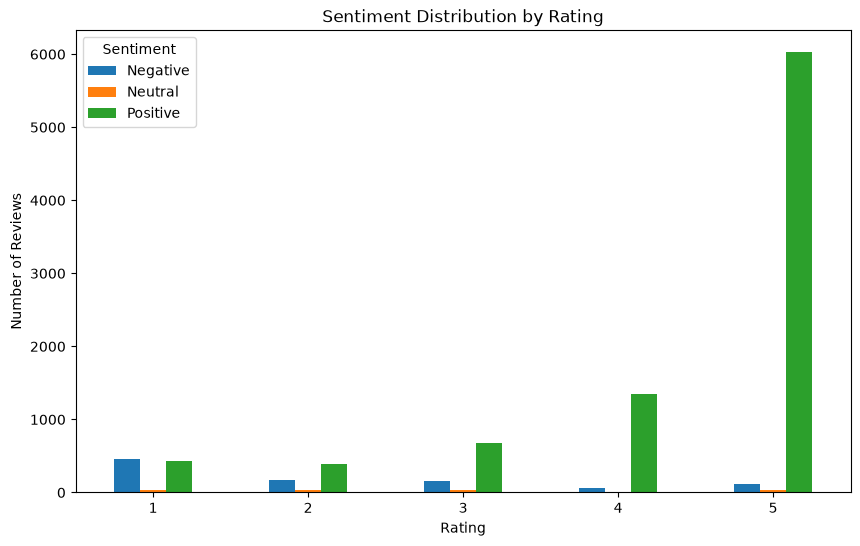

In [32]:
sentiment_rating.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Sentiment Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.show()

In [33]:
average_sentiment = df.groupby("Score")[
    "Sentiment_Score"
].mean()

print(average_sentiment)

Score
1   -0.017199
2    0.342107
3    0.518896
4    0.780872
5    0.844794
Name: Sentiment_Score, dtype: float64


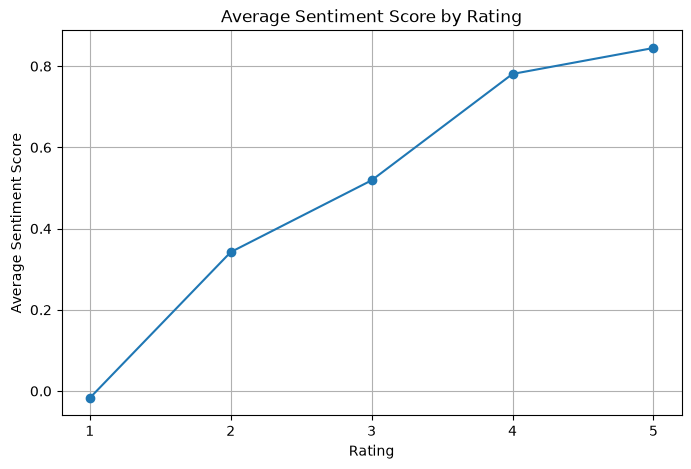

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    average_sentiment.index,
    average_sentiment.values,
    marker="o"
)

plt.title("Average Sentiment Score by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Sentiment Score")

plt.xticks([1, 2, 3, 4, 5])

plt.grid(True)

plt.show()

In [35]:
avg_length = df.groupby("Sentiment")[
    "Review_Length"
].mean()

print(avg_length)

Sentiment
Negative    402.582292
Neutral     295.601351
Positive    419.896761
Name: Review_Length, dtype: float64


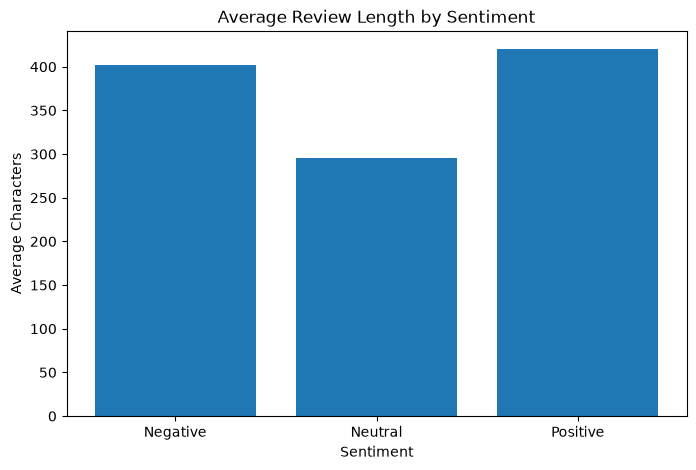

In [36]:
plt.figure(figsize=(8,5))

plt.bar(
    avg_length.index,
    avg_length.values
)

plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Characters")

plt.show()

In [37]:
positive_text = " ".join(
    positive_reviews["Clean_Review"]
)

In [38]:
positive_words = positive_text.split()

positive_counter = Counter(positive_words)

positive_counter.most_common(20)

[('the', 28775),
 ('i', 25876),
 ('and', 20385),
 ('a', 18861),
 ('it', 16794),
 ('to', 15473),
 ('of', 12453),
 ('is', 11367),
 ('this', 10674),
 ('for', 9009),
 ('in', 8002),
 ('my', 7192),
 ('that', 6597),
 ('but', 6092),
 ('you', 5931),
 ('with', 5798),
 ('s', 5308),
 ('not', 5279),
 ('have', 5274),
 ('are', 5086)]

In [39]:
negative_text = " ".join(
    negative_reviews["Clean_Review"]
)

negative_words = negative_text.split()

negative_counter = Counter(negative_words)

negative_counter.most_common(20)

[('the', 3354),
 ('i', 2811),
 ('and', 1864),
 ('a', 1737),
 ('it', 1736),
 ('to', 1537),
 ('of', 1380),
 ('this', 1174),
 ('is', 1154),
 ('not', 1063),
 ('in', 917),
 ('that', 749),
 ('was', 721),
 ('for', 721),
 ('but', 676),
 ('my', 597),
 ('t', 556),
 ('have', 529),
 ('with', 508),
 ('you', 496)]

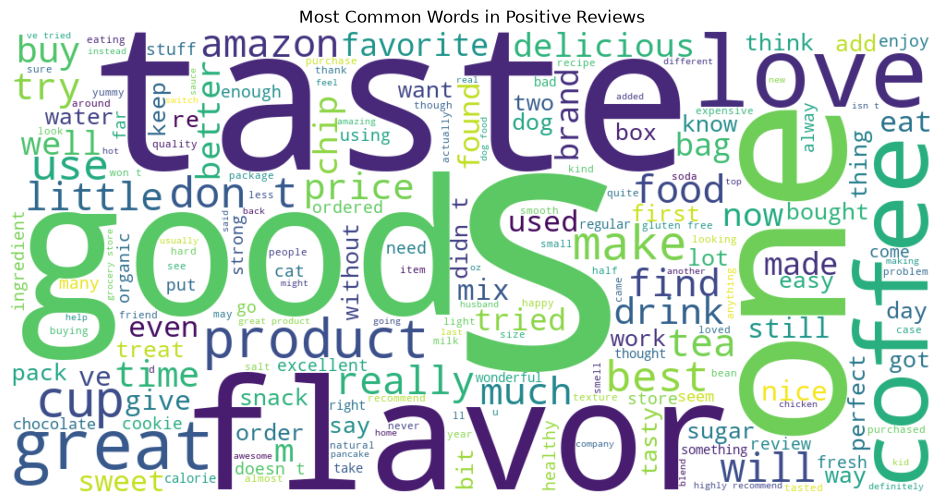

In [40]:
positive_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(
    positive_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Most Common Words in Positive Reviews")

plt.show()

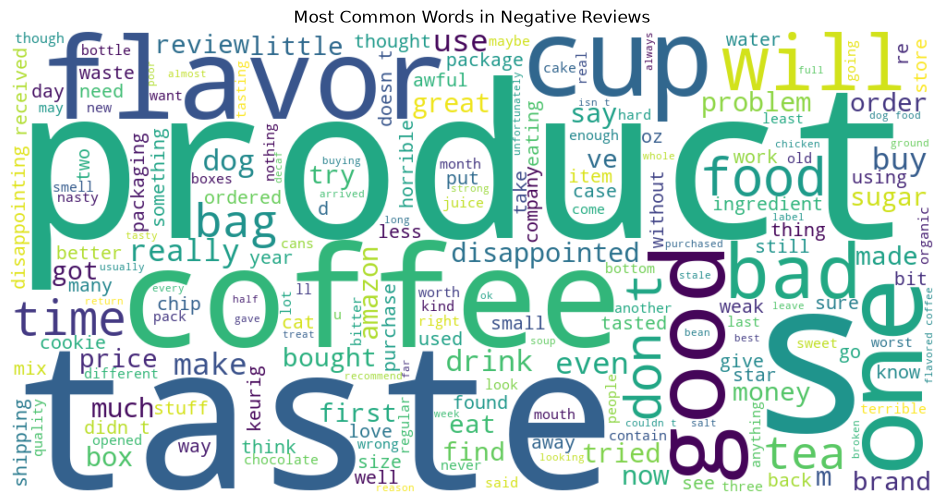

In [41]:
negative_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(
    negative_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Most Common Words in Negative Reviews")

plt.show()

emotion_words = {
    "Joy": [
        "love", "happy", "excellent", "amazing",
        "wonderful", "great", "fantastic", "awesome"
    ],
    
    "Anger": [
        "angry", "hate", "worst", "terrible",
        "annoying", "awful", "furious"
    ],
    
    "Sadness": [
        "sad", "disappointed", "unhappy",
        "sorry", "cry", "depressing"
    ],
    
    "Fear": [
        "fear", "scared", "afraid",
        "danger", "worry", "worried"
    ],
    
    "Surprise": [
        "surprised", "unexpected",
        "wow", "shocking", "amazing"
    ],
    
    "Disgust": [
        "disgusting", "gross",
        "nasty", "horrible", "dislike"
    ],
    
    "Trust": [
        "trust", "safe", "reliable",
        "honest", "recommend"
    ]
}

In [44]:
def detect_emotion(text):
    words = set(text.split())
    
    emotion_scores = {}
    
    for emotion, keywords in emotion_words.items():
        count = sum(
            1 for word in keywords
            if word in words
        )
        
        emotion_scores[emotion] = count
    
    max_emotion = max(
        emotion_scores,
        key=emotion_scores.get
    )
    
    if emotion_scores[max_emotion] == 0:
        return "No Clear Emotion"
    
    return max_emotion

In [45]:
df["Emotion"] = df["Clean_Review"].apply(
    detect_emotion
)

df[
    ["Clean_Review", "Sentiment", "Emotion"]
].head(20)

,Clean_Review,Sentiment,Emotion
0,good quality dog food i have bought several of...,Positive,No Clear Emotion
1,not as advertised product arrived labeled as j...,Negative,No Clear Emotion
2,delight says it all this is a confection that ...,Positive,Trust
3,cough medicine if you are looking for the secr...,Positive,No Clear Emotion
4,great taffy great taffy at a great price there...,Positive,Joy
5,nice taffy i got a wild hair for taffy and ord...,Positive,Trust
6,great just as good as the expensive brands thi...,Positive,Joy
7,wonderful tasty taffy this taffy is so good it...,Positive,Joy
8,yay barley right now i m mostly just sprouting...,Positive,Joy
9,healthy dog food this is a very healthy dog fo...,Positive,No Clear Emotion


In [46]:
emotion_counts = df["Emotion"].value_counts()

print(emotion_counts)

Emotion
Joy                 5345
No Clear Emotion    3601
Trust                303
Sadness              230
Anger                226
Surprise             127
Disgust              124
Fear                  44
Name: count, dtype: int64


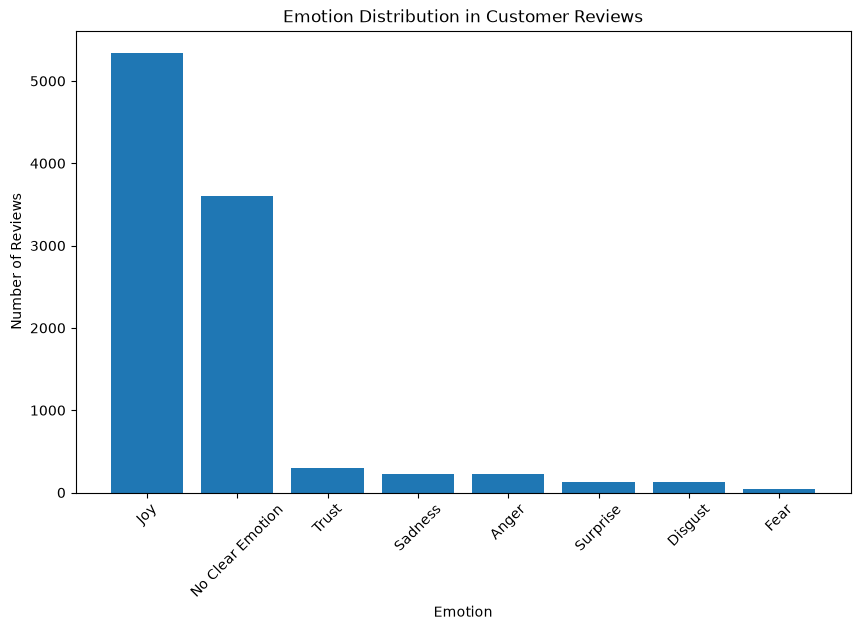

In [47]:
plt.figure(figsize=(10,6))

plt.bar(
    emotion_counts.index,
    emotion_counts.values
)

plt.title("Emotion Distribution in Customer Reviews")
plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.show()

In [48]:
sentiment_emotion = pd.crosstab(
    df["Sentiment"],
    df["Emotion"]
)

sentiment_emotion

Emotion,Anger,Disgust,Fear,Joy,No Clear Emotion,Sadness,Surprise,Trust
Sentiment,,,,,,,,
Negative,122,56,6,159,488,93,10,26
Neutral,4,5,1,19,110,5,1,3
Positive,100,63,37,5167,3003,132,116,274


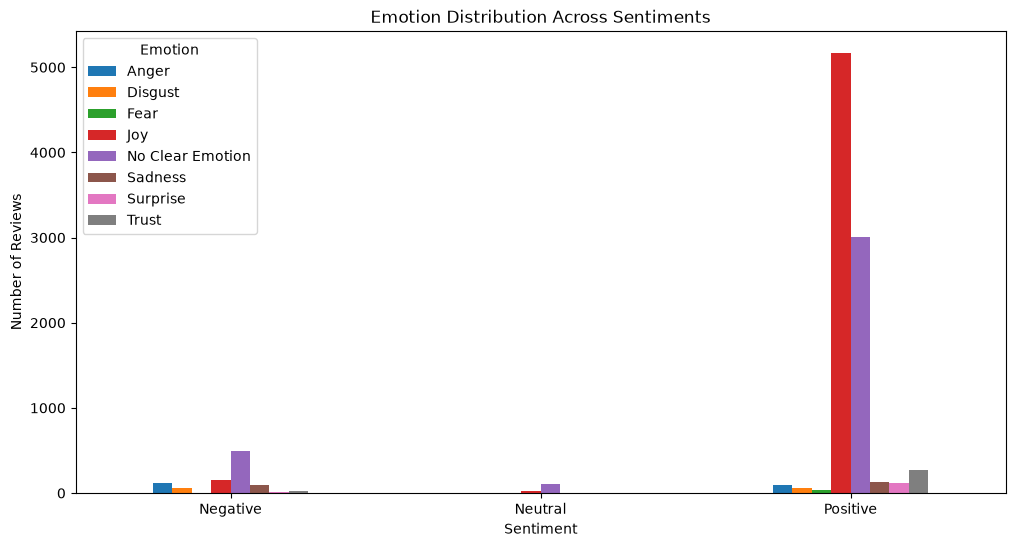

In [49]:
sentiment_emotion.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Emotion Distribution Across Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.show()

# Business Insights

### 1. Customer Sentiment
Sentiment analysis helps identify whether customers are generally satisfied, dissatisfied, or neutral.

### 2. Product Improvement
Negative reviews can help businesses identify product quality, packaging, delivery, taste, or service-related problems.

### 3. Customer Satisfaction
Positive reviews indicate areas where customers are satisfied and where the business is performing well.

### 4. Emotion Analysis
Emotion detection provides deeper information about customer reactions such as joy, anger, sadness, fear, surprise, disgust, and trust.

### 5. Marketing Strategy
Positive customer opinions can help businesses identify products and features that can be highlighted in marketing campaigns.

### 6. Product Development
Frequent negative words and emotions can be analyzed to identify areas for product improvement.

In [50]:
summary = pd.DataFrame({
    "Metric": [
        "Total Reviews",
        "Positive Reviews",
        "Negative Reviews",
        "Neutral Reviews"
    ],
    
    "Value": [
        len(df),
        (df["Sentiment"] == "Positive").sum(),
        (df["Sentiment"] == "Negative").sum(),
        (df["Sentiment"] == "Neutral").sum()
    ]
})

summary

,Metric,Value
0,Total Reviews,10000
1,Positive Reviews,8892
2,Negative Reviews,960
3,Neutral Reviews,148


In [51]:
df.to_csv(
    "amazon_sentiment_analysis.csv",
    index=False
)

print("File saved successfully!")

File saved successfully!


# Conclusion

This project successfully performed sentiment analysis on Amazon customer reviews using Natural Language Processing.

The reviews were classified into Positive, Negative, and Neutral categories using the VADER sentiment lexicon.

Emotion detection was also performed to identify emotions such as Joy, Anger, Sadness, Fear, Surprise, Disgust, and Trust.

The analysis and visualizations provide useful insights into customer opinions and can help businesses improve products, customer experience, and marketing strategies.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- NLTK
- VADER Sentiment Analyzer
- WordCloud
- Jupyter Notebook